In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc

In [2]:
df = pd.read_csv('ThoraricSurgery.csv', header=None)

In [3]:
print(f'데이터 크기: {df.shape}')
print(df.head())

데이터 크기: (470, 18)
    0   1     2     3   4   5   6   7   8   9   10  11  12  13  14  15  16  17
0  293   1  3.80  2.80   0   0   0   0   0   0  12   0   0   0   1   0  62   0
1    1   2  2.88  2.16   1   0   0   0   1   1  14   0   0   0   1   0  60   0
2    8   2  3.19  2.50   1   0   0   0   1   0  11   0   0   1   1   0  66   1
3   14   2  3.98  3.06   2   0   0   0   1   1  14   0   0   0   1   0  80   1
4   17   2  2.21  1.88   0   0   1   0   0   0  12   0   0   0   1   0  56   0


In [4]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [5]:
model = LogisticRegression(solver='lbfgs', max_iter=2000)
model.fit(x, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [6]:
y_pred = model.predict(x)
y_prob = model.predict_proba(x)[:, 1]

In [7]:
acc = accuracy_score(y, y_pred)
print(f'Accuracy: {acc:.4f}')

cm = confusion_matrix(y, y_pred)
print('Confusion Matrix:')
print(cm)

roc_auc = roc_auc_score(y, y_prob)
print(f'ROC AUC: {roc_auc:.4f}')

f1 = f1_score(y, y_pred)
print(f'F1 Score: {f1:.4f}')

precision, recall, thresholds = precision_recall_curve(y, y_prob)
pr_auc = auc(recall, precision)
print(f'PR AUC: {pr_auc:.4f}')

Accuracy: 0.8468
Confusion Matrix:
[[397   3]
 [ 69   1]]
ROC AUC: 0.7352
F1 Score: 0.0270
PR AUC: 0.3193


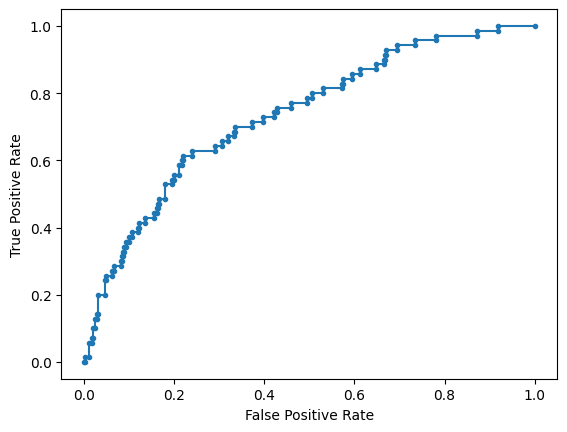

In [8]:
fpr, tpr, _ = roc_curve(y, y_prob)

plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

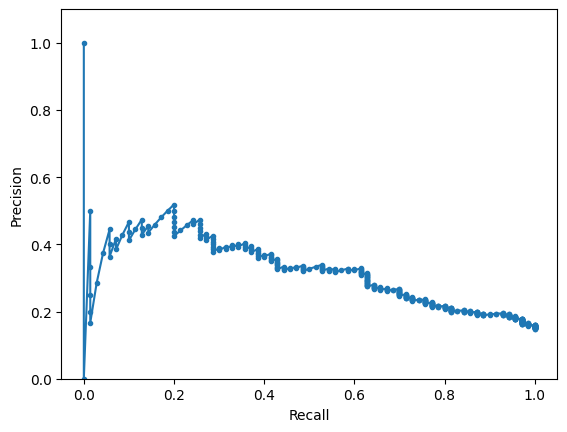

In [9]:
plt.plot(recall, precision, marker='.')
plt.ylim(.0, 1.1)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

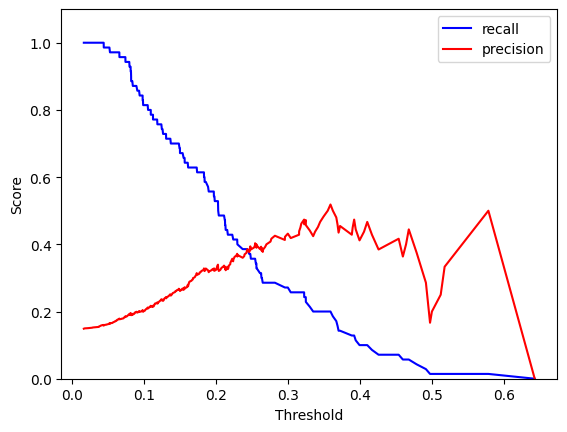

In [10]:
plt.plot(thresholds, recall[:len(thresholds)], label='recall', color='blue')
plt.plot(thresholds, precision[:len(thresholds)], label='precision', color='red')
plt.ylim(.0, 1.1)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()